In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error

In [27]:
PROJECT_ROOT = Path("..")

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
DATA_LATENT = PROJECT_ROOT / "data" / "latent"
DATA_BACKTESTS = PROJECT_ROOT / "data" / "backtests"

DATA_BACKTESTS.mkdir(parents=True, exist_ok=True)

latent_df = pd.read_parquet(DATA_LATENT / "fc_vae_latents.parquet")
returns = pd.read_parquet(DATA_PROCESSED / "returns.parquet")

latent_df["date"] = pd.to_datetime(latent_df["date"])
returns.index = pd.to_datetime(returns.index)

latent_df.head()


,date,ticker,z_0,z_1,z_2,z_3,z_4,z_5,z_6,z_7
0,2015-09-21,AAPL,-0.619362,-0.291282,1.218507,-1.537995,-0.378683,-0.759858,0.066653,-0.840747
1,2015-09-22,AAPL,-0.727026,-0.177698,1.383948,-1.456320,-0.351501,-0.799361,-0.037340,-0.873263
2,2015-09-23,AAPL,-0.811343,-0.079573,1.356158,-1.388889,-0.337329,-0.717278,-0.089436,-0.947264
3,2015-09-24,AAPL,-0.956392,0.021238,1.388825,-1.334907,-0.281220,-0.718173,-0.138247,-0.959101
4,2015-09-25,AAPL,-1.019286,0.120451,1.327576,-1.271330,-0.350556,-0.711358,-0.211038,-0.988253


In [28]:
np.shape(latent_df)

(70080, 10)

In [29]:
HORIZON = 5

future_returns = (
    returns
    .shift(-1)
    .rolling(HORIZON)
    .sum()
)

In [30]:
future_return_list = []

for _, row in latent_df[["date", "ticker"]].iterrows():
    date = row["date"]
    ticker = row["ticker"]

    try:
        future_return_list.append(future_returns.loc[date, ticker])
    except KeyError:
        future_return_list.append(np.nan)

latent_df["target_return_5d"] = future_return_list

latent_df = latent_df.dropna(subset=["target_return_5d"]).copy()

latent_df.shape

(70050, 11)

In [31]:
z_cols = [c for c in latent_df.columns if c.startswith("z_")]

X = latent_df[z_cols].values
y = latent_df["target_return_5d"].values

X.shape, y.shape

((70050, 8), (70050,))

In [32]:
dates = np.sort(latent_df["date"].unique())

split_date = dates[int(0.7 * len(dates))]

split_date

np.datetime64('2022-03-17T00:00:00.000000000')

In [33]:
train_mask = latent_df["date"] < split_date
test_mask = latent_df["date"] >= split_date

X_train = latent_df.loc[train_mask, z_cols].values
y_train = latent_df.loc[train_mask, "target_return_5d"].values

X_test = latent_df.loc[test_mask, z_cols].values
y_test = latent_df.loc[test_mask, "target_return_5d"].values

X_train.shape, X_test.shape

((49020, 8), (21030, 8))

In [34]:
ridge_model = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=10.0))
])

ridge_model.fit(X_train, y_train)

y_pred_train = ridge_model.predict(X_train)
y_pred_test = ridge_model.predict(X_test)

print("Train MSE:", mean_squared_error(y_train, y_pred_train))
print("Test MSE:", mean_squared_error(y_test, y_pred_test))

print("Train corr:", np.corrcoef(y_train, y_pred_train)[0, 1])
print("Test corr:", np.corrcoef(y_test, y_pred_test)[0, 1])

Train MSE: 0.0017994379983262453
Test MSE: 0.0022034182722166593
Train corr: 0.1065909607759524
Test corr: 0.08593670654966483


/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/holloaron/vae_trading_project/v

In [35]:
latent_df["score_ridge"] = ridge_model.predict(latent_df[z_cols].values)

latent_df[["date", "ticker", "target_return_5d", "score_ridge"]].head()

/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


,date,ticker,target_return_5d,score_ridge
0,2015-09-21,AAPL,-0.024595,0.007065
1,2015-09-22,AAPL,-0.017599,0.007268
2,2015-09-23,AAPL,0.009738,0.007728
3,2015-09-24,AAPL,0.011342,0.008136
4,2015-09-25,AAPL,-0.023960,0.008158


In [36]:
def make_long_short_positions(df, score_col, long_q=0.8, short_q=0.2):
    out = []

    for date, g in df.groupby("date"):
        g = g.copy()

        long_threshold = g[score_col].quantile(long_q)
        short_threshold = g[score_col].quantile(short_q)

        g["position"] = 0
        g.loc[g[score_col] >= long_threshold, "position"] = 1
        g.loc[g[score_col] <= short_threshold, "position"] = -1

        out.append(g)

    return pd.concat(out, axis=0)

In [37]:
strategy_df = make_long_short_positions(
    latent_df,
    score_col="score_ridge",
    long_q=0.8,
    short_q=0.2
)

strategy_df["position"].value_counts()

position
 0    42030
 1    14010
-1    14010
Name: count, dtype: int64

In [38]:
next_returns = returns.shift(-1)

In [39]:
next_return_list = []

for _, row in strategy_df[["date", "ticker"]].iterrows():
    date = row["date"]
    ticker = row["ticker"]

    try:
        next_return_list.append(next_returns.loc[date, ticker])
    except KeyError:
        next_return_list.append(np.nan)

strategy_df["next_return_1d"] = next_return_list
strategy_df = strategy_df.dropna(subset=["next_return_1d"]).copy()

In [40]:
strategy_df["asset_strategy_return"] = (
    strategy_df["position"] * strategy_df["next_return_1d"]
)

In [41]:
portfolio_returns = (
    strategy_df
    .groupby("date")["asset_strategy_return"]
    .mean()
)

In [42]:
def performance_stats(r):
    r = r.dropna()

    total_return = (1 + r).prod() - 1
    ann_return = (1 + total_return) ** (252 / len(r)) - 1
    ann_vol = r.std() * np.sqrt(252)
    sharpe = ann_return / ann_vol if ann_vol > 0 else np.nan

    equity = (1 + r).cumprod()
    running_max = equity.cummax()
    drawdown = equity / running_max - 1
    max_drawdown = drawdown.min()

    return pd.Series({
        "total_return": total_return,
        "ann_return": ann_return,
        "ann_vol": ann_vol,
        "sharpe": sharpe,
        "max_drawdown": max_drawdown,
    })

In [43]:
stats = performance_stats(portfolio_returns)

stats

total_return    0.349736
ann_return      0.032897
ann_vol         0.049826
sharpe          0.660228
max_drawdown   -0.111007
dtype: float64

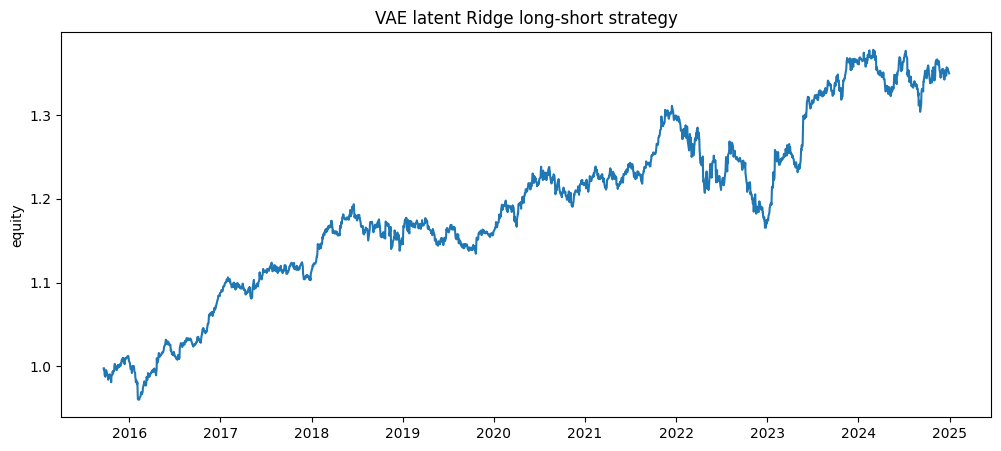

In [44]:
equity = (1 + portfolio_returns).cumprod()

plt.figure(figsize=(12, 5))
plt.plot(equity)
plt.title("VAE latent Ridge long-short strategy")
plt.ylabel("equity")
plt.show()

In [45]:
test_dates = latent_df.loc[test_mask, "date"].unique()

portfolio_returns_test = portfolio_returns.loc[
    portfolio_returns.index.isin(test_dates)
]

performance_stats(portfolio_returns_test)

total_return    0.067179
ann_return      0.023649
ann_vol         0.059824
sharpe          0.395307
max_drawdown   -0.093070
dtype: float64

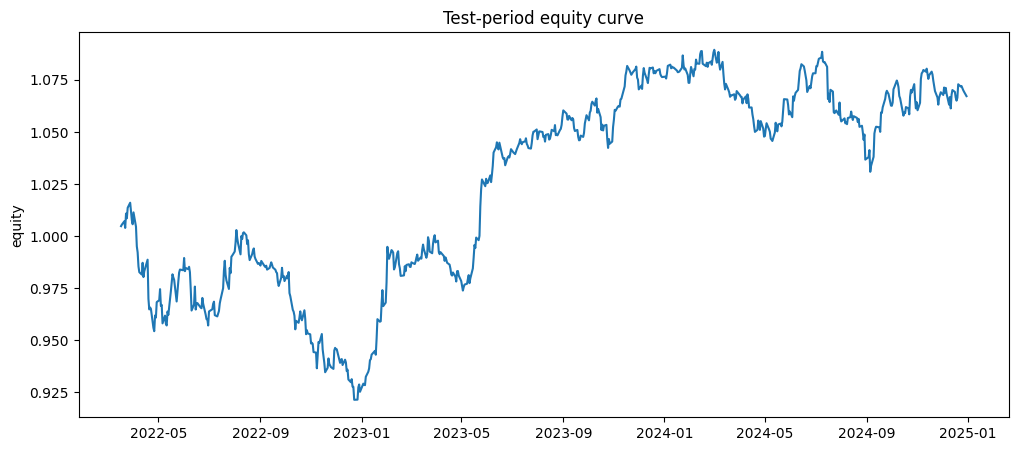

In [46]:
equity_test = (1 + portfolio_returns_test).cumprod()

plt.figure(figsize=(12, 5))
plt.plot(equity_test)
plt.title("Test-period equity curve")
plt.ylabel("equity")
plt.show()

In [47]:
strategy_df.to_parquet(DATA_BACKTESTS / "vae_ridge_strategy_df.parquet")
portfolio_returns.to_frame("vae_ridge_return").to_parquet(
    DATA_BACKTESTS / "vae_ridge_portfolio_returns.parquet"
)

In [48]:
print("Test corr:", np.corrcoef(y_test, y_pred_test)[0, 1])
performance_stats(portfolio_returns_test)

Test corr: 0.08593670654966483


total_return    0.067179
ann_return      0.023649
ann_vol         0.059824
sharpe          0.395307
max_drawdown   -0.093070
dtype: float64